In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
mne.set_log_level('WARNING')
print("MNE version:" + mne.__version__)

MNE version:1.11.0


Step 1: Get the EEG data. Lets start with subject 1 run 4 to geth the EEG data from one person on one motor imagery task.

In [2]:
subject = 1
runs = [4]
#Gets the files for the subject and runs specified.
file_names =mne.datasets.eegbci.load_data(subject, runs)
#Loads the first file and prints its information. Preload=true means the data will be loaded into memory.
raw_files = mne.io.read_raw_edf(file_names[0], preload=True)
print(raw_files)

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


Step 2: Print and visualise the data to get a better understanding of its structure.

In [3]:
print(raw_files.info)
print("Number of channels:" + str(len(raw_files.ch_names)))
print("Channel names:" + str(raw_files.ch_names))
print("Channel types:" + str(raw_files.get_channel_types()))
print("Sampling Frequency:" + str(raw_files.info['sfreq']))
print("Total time points:" + str(raw_files.n_times))
print("Duration in seconds:" + str(raw_files.times[-1]))
print("Nyquist Frequency:" + str(raw_files.info['sfreq'] / 2))

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Number of channels:64
Channel names:['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']
Channel types:['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'e

Step 3: Clean up the channel names and set the electrode positions. We need to tell mne where the electrodes are placed on the scalp in order to form a topographic map. This allows us to make spatial distinctions in our data, for example C4 which sits over right motor cortex showed a ERD in mu rythms.

In [5]:
#Ensure naming follows standard convention of the 10-20 system. (C3, C4).
mne.datasets.eegbci.standardize(raw_files)

#Create a montage for the standard 10-20 system and set it for the standardised data. This will help with
#visualisation by attaching a 3D location to each channel. It is a table of known electrode names and their
#respective coordinates on the scalp.
montage = mne.channels.make_standard_montage('standard_1020')

#Attach the montage to the data.
raw_files.set_montage(montage)

print(raw_files.info)

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


Step 4: Plot the electrode positions, by visualising where the 64 electrodes are on the scalp and identifying C3, C4. Left side of image = left side of head, nose is at the top of the diagram. C line runs horizontally across the middle of the scalp, odd numbers are left hemisphere and even are right hemisphere. 

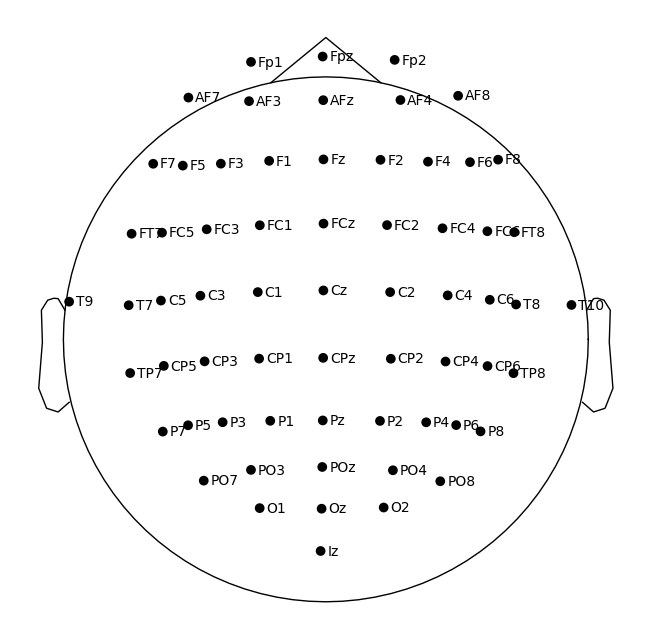

C:\Users\leogr\AppData\Local\Temp\ipykernel_28956\1229351920.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  sensor_plot.show()


In [8]:
#Plot sensor layout.
sensor_plot = raw_files.plot_sensors(show_names=True)
sensor_plot.show()

Step 5: Extract and examine the raw numpy array.

In [ ]:
data = raw_files.get_data()
print("Data shape (channels x time points):" + str(data.shape))
print("Data type:" + str(data.dtype))
#Multiply by 1e6 to convert volts into microvolts. MNE stores EEG data in volts.
print("Value range in microvolts:" + str((data.min()*1e6, data.max()*1e6)))
print("Mean amplitude microvolts:" + str(data.mean()*1e6))
print("Standard deviation in microvolts:" + str(data.std()*1e6), "Standard deviation in volts:" + str(data.std()))

Data shape (channels x time points):(64, 20000)
Data type:float64
Value range in microvolts:(np.float64(-376.0), np.float64(594.9999999999999))
Mean amplitude microvolts:-1.4307812499999997 Mean amplitude volts:-1.4307812499999997e-06
Standard deviation in microvolts:53.503149098461 Standard deviation in volts:5.3503149098461e-05


Step 6: Here we plot the raw time series from C3 and C4. We do this to see what the raw EEG actually looks like as a waveform. We will see a rapidly oscillating noisy waveform. This is normal for an EEG due to the large populations of neurons, brain areas and noise it captures. We wont see any events here, as the motor signal is hidden among the numerous frequencies in the signal. This is the challenge of BCI, the event signal is not in the raw waveform, it is captured in the frequency content of the waveform.

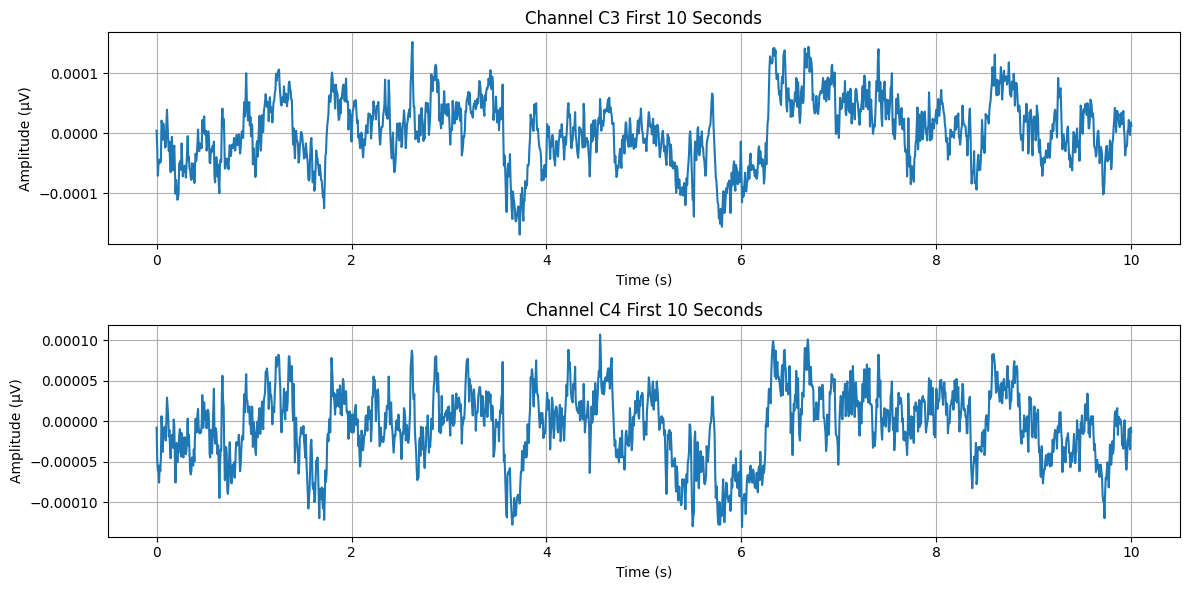

In [ ]:
#Find the index of C3 and C4 channels in the channel list. This will be used to extract data from these.
c3_index = raw_files.ch_names.index('C3')
c4_index = raw_files.ch_names.index('C4')

#Get the time vector from the files. Actual time values for each sample point. Here sampling freq is
#160 Hz and we are measuring for 124 seconds so we should have 160*124 = 19840 time points.
times = raw_files.times

#Choose a time window of interest. Here we take the first 10 seconds of data. Calculate start and end
#indices based on the sampling frequency and time vector. 
time_window = (times >= 0) & (times <= 10)
#Take the first sample point where the time window is true and the last sample point where the time
#window is true to get the start and end indices for the time window.
start_index = np.where(time_window)[0][0]
end_index = np.where(time_window)[0][-1]

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
#Extract data and plot for C3 and C4 channels. We use get_data with picks to specify which channel
#we want and start and stop to specify the time window. This gives a 2D array of shape (1, amplitude at
# each time point). We then flatten this into a 1D array for plotting. We plot with time on the x-axis
#and amplitude on the y-axis.
#
for c in range(2):
    channel_data = raw_files.get_data(picks=[c3_index, c4_index][c],
                                       start=start_index, stop=end_index + 1)
    channel_data = channel_data.flatten()
    ax[c].plot(times[time_window], channel_data)
    ax[c].set_title(f"Channel {['C3', 'C4'][c]} First 10 Seconds")
    ax[c].set_ylabel("Amplitude (µV)")
    ax[c].set_xlabel("Time (s)")
    ax[c].grid(True)
plt.tight_layout()
plt.show()


Step 7: Extract the events from the recording by finding the event markers that tell us when each imagery trial started and what type it was.

In [14]:
#Extract events from the data. Returns the event name and the corresponding integer code.
#The events are stored as annotations in the raw data, and this function converts them into a
#standard event array format. Each row corresponds to an event and has three columns:
#Sample index where the event occurs, duration (usually 0) and event code (type of event).
#Also returns event_id, which is a dictionary mapping event labels to codes. 
events, event_id = mne.events_from_annotations(raw_files)

#Print event id mapping. This shows the mapping of event labels to integer codes. 
#(T0 for rest, T1 for left etc...)
print("Event ID mapping:" + str(event_id))
print("Total events found:" + str(len(events)))
print("First 5 events:" + str(events[:5]))

#count how many events of each type we have. event_id.items() returns pairs of (event name, event code).
#We extract the third column (id) from all rows (events) and compare it to the event code for each 
#event type. This gives a boolean array where True indicates a match. We sum this boolean array to get
#the total count of events for that type. We print the event name, code and count for each.
for name, code in event_id.items():
    count = np.sum(events[:, 2] == code)
    print(f"'{name}' (code {code}): {count} events")
    


Event ID mapping:{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total events found:30
First 5 events:[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]]
'T0' (code 1): 15 events
'T1' (code 2): 8 events
'T2' (code 3): 7 events


Step 8: Visualise the event timeline. Here we plot when each type of event occured in the recording so we can observe the experimental method.

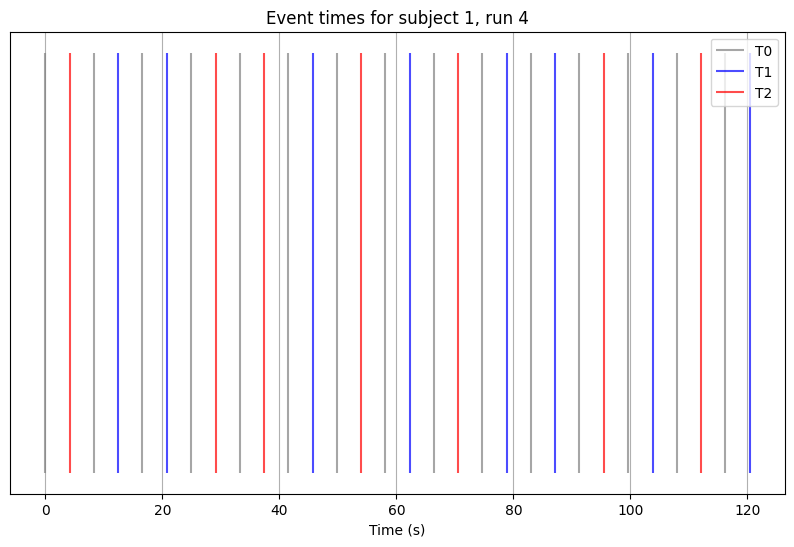

In [21]:
fig = plt.figure(figsize=(10, 6))
#To later color grade the events in the plot.
colors = {'T0': 'gray', 'T1': 'blue', 'T2': 'red'}
for event_type in event_id.keys():
    #Get the event code for the current event type from the event_id dictionary.
    event_code = event_id[event_type]
    #Take all rows of the events array and compare it to the event code for the current event type.
    #This gives a boolean array where we keep the rows where the event codes match the current event type.
    #From these rows, take the first column (sample times) and convert them into seconds by subtracting
    #the first sample time and dividing by the sampling frequency. Returns the sample times for the event.
    event_times = events[events[:, 2] == event_code, 0]
    event_time_sec = (event_times - raw_files.first_samp) / raw_files.info['sfreq']
    #Plot a vertical line at each event time with a label for the event type. We use alpha to make the lines
    #semi-transparent and we have a different color for each event type.
    plt.vlines(event_time_sec, ymin=0, ymax=1, label=event_type, alpha=0.7, color=colors[event_type])
plt.title("Event times for subject 1, run 4")
plt.xlabel("Time (s)")
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()


Step 9: Power Spectral Density. Now we look at the actual frequency content of the EEG at C3 and C4. Find the mu rythm peak. This is the first visualisation where we can see our signal of interest. To do this we leveradge fourier analysis, decomposing our aggregate signal into a sum of sine waves at different frequencies. The Power Spectral Density (PSD) shows how much power (amplitude^2) exists at each frequency. It shows how the signals power is distributed across frequencies. For EEG, this reveals the dominant neural oscillations. Here we want our customary C3, and C4 electrodes, as these are the most relevant for measuring mu and beta rythms. We can see a small peak in the mu band in the plot. THis is what gets supress during ERD.

c:\Portfolio\Movement Predictor\.venv\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


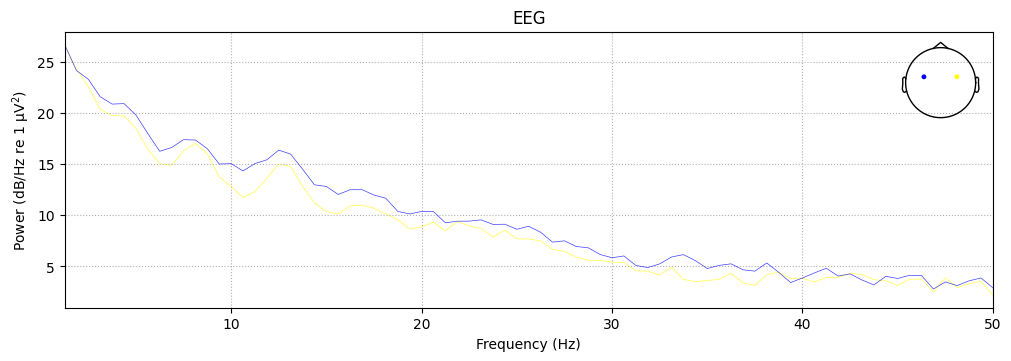

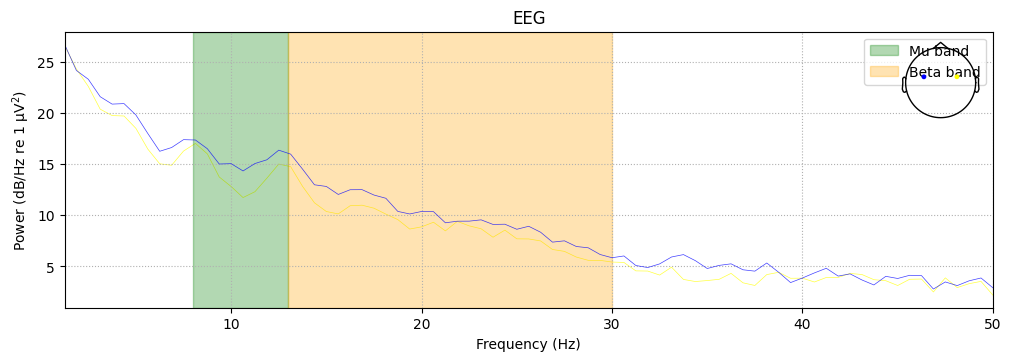

In [30]:
picks = mne.pick_channels(raw_files.ch_names, include=['C3', 'C4'])

spectrum = raw_files.compute_psd(method='welch', picks=picks, fmin=1, fmax=50, n_fft=256)
spectrum.plot()

fig = spectrum.plot(show=False)
ax = fig.axes[0]
ax.axvspan(8, 13, color='green', alpha=0.3, label='Mu band')
ax.axvspan(13, 30, color='orange', alpha=0.3, label='Beta band')
ax.legend()
plt.show()


Step 10: Epoch data. Here we cut the continous recording into trial sized segments labeled by condition. This transforms data from 2D (channels, total_time) to 3D (trials, channels, trial_time). The continous recording mixes different events. In order to compare conditions, we need to isolate the time segment corresponding to each trial (one trial is one event). We call such a segment an epoch, a snapshot in time.

In [31]:
#Which events we want to consider, not T0 (rest) as this is trivial.
event_id_imagery = {'T1': 2, 'T2': 3} #left fist right fist.

#Create the epochs. tmin=-1 says start 1 second before the event onset. Load all epochs into memory. 
epochs = mne.Epochs(raw_files, events, event_id=event_id_imagery, tmin=-1, tmax=4, baseline=None, 
                    picks=picks, preload=True)
print(epochs)
print("Trials for T1 (left fist):" + str(len(epochs['T1'])))
print("Trials for T2 (right fist):" + str(len(epochs['T2'])))

#Get the data from the epochs. This gives a 3D array (trials, channels, time points). 
#E.g (20, 64, 800) says that we have 20 trials across 64 channels and 800 time points in each trial.
#each trial is a segment of data around an event. Every model we build will take this 3D array as input.
print(epochs.get_data().shape)



<Epochs | 15 events (all good), -1 – 4 s (baseline off), ~223 KiB, data loaded,
 'T1': 8
 'T2': 7>
Trials for T1 (left fist):8
Trials for T2 (right fist):7
(15, 2, 801)


Step 11: Now we start comparing PSD between conditions. We compare the power spectrum at C3 and C4 for left vs right imagery trials. Here we should see ERD.

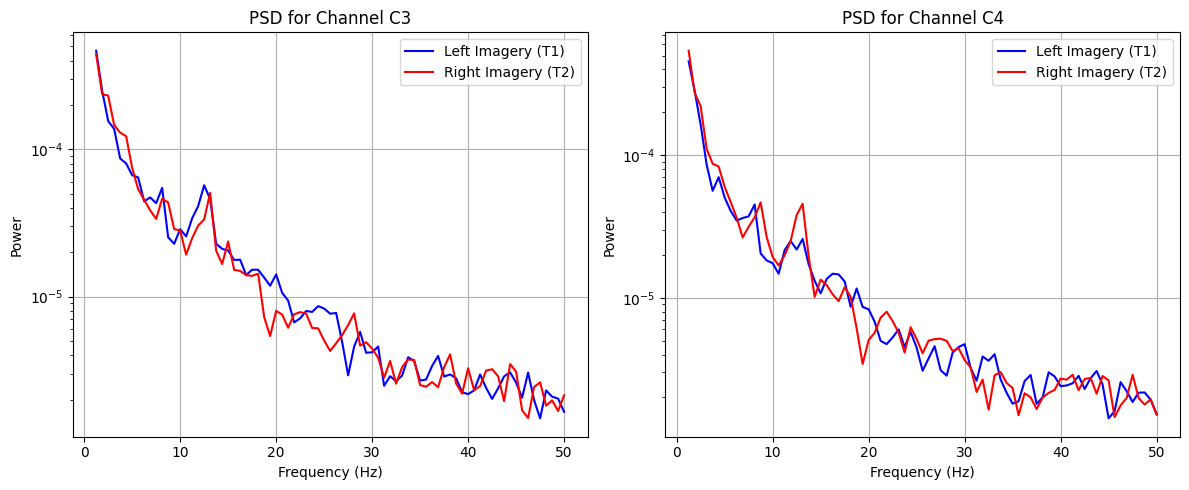

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
channels = ['C3', 'C4']
for i, channel_name in enumerate(channels):
    #get the channel name.
    pick = mne.pick_channels(epochs.ch_names, include=[channel_name])
    #Compute the PSD for left imagery epochs/trials using Welch method. This gives us the average power
    #at each frequency across all trials for the left imagery condition (C4, T1).
    psd_left = epochs['T1'].compute_psd(method='welch', picks=pick, fmin=1, fmax=50,
                                        n_fft=256)
    #Extract data from psd_left. This gives 3D array (n_epochs, n_channels, n_freqs). mean(axis=0)
    #averages across all trials to give us average power at each frequency. squeeze() removes
    #any single dimensions such as the channel.
    psd_left_data = psd_left.get_data().mean(axis=0).squeeze()
    freqs_left = psd_left.freqs

    #Same for right imagery (C3, T2).
    psd_right = epochs['T2'].compute_psd(method='welch', picks=pick, fmin=1, fmax=50,
                                         n_fft=256)
    psd_right_data = psd_right.get_data().mean(axis=0).squeeze()
    freqs_right = psd_right.freqs

    #plot with log scale on y-axis to better visualise differences in power across frequencies.
    ax[i].plot(freqs_left, psd_left_data*1e6, label='Left Imagery (T1)', color='blue')
    ax[i].plot(freqs_right, psd_right_data*1e6, label='Right Imagery (T2)', color='red')
    ax[i].set_xlabel('Frequency (Hz)')
    ax[i].set_ylabel('Power')
    ax[i].set_title(f'PSD for Channel {channel_name}')
    ax[i].legend()
    ax[i].set_yscale('log')
    ax[i].grid(True)
plt.tight_layout()
plt.show()


Step 12: Now combine runs 4, 8 and 12 to make for a total of 7*3 = 21 trials per class. This cleans up data as noise gets cancelled out and the ERD should be more visible. Rerun code from above but with all_epochs.

In [45]:
runs = [4, 8, 12]
subject = 1
#Download all 3 runs.
raw_fnames_all = mne.datasets.eegbci.load_data(subject, runs)

#load each of them into a raw object.
raw_files_all = [mne.io.read_raw_edf(fname, preload=True) for fname in raw_fnames_all]

#Concatenate the raw objects into one continous recording. This will allow us to have more data for
#training our model. We also want a single event array.
raw_all = mne.concatenate_raws(raw_files_all)

#Clean up the data.
mne.datasets.eegbci.standardize(raw_all)
montage = mne.channels.make_standard_montage('standard_1020')
raw_all.set_montage(montage)

#Extract all events from the data. This will give us a single event array.
events_all, event_id_all = mne.events_from_annotations(raw_all)
epochs_all = mne.Epochs(raw_all, events_all, event_id=event_id_all, tmin=-1, tmax=4, baseline=None,
                    picks=picks, preload=True)
#Trial count per class.
print("Trials for T1 (left fist):" + str(len(epochs_all['T1'])))
print("Trials for T2 (right fist):" + str(len(epochs_all['T2'])))

Trials for T1 (left fist):23
Trials for T2 (right fist):22


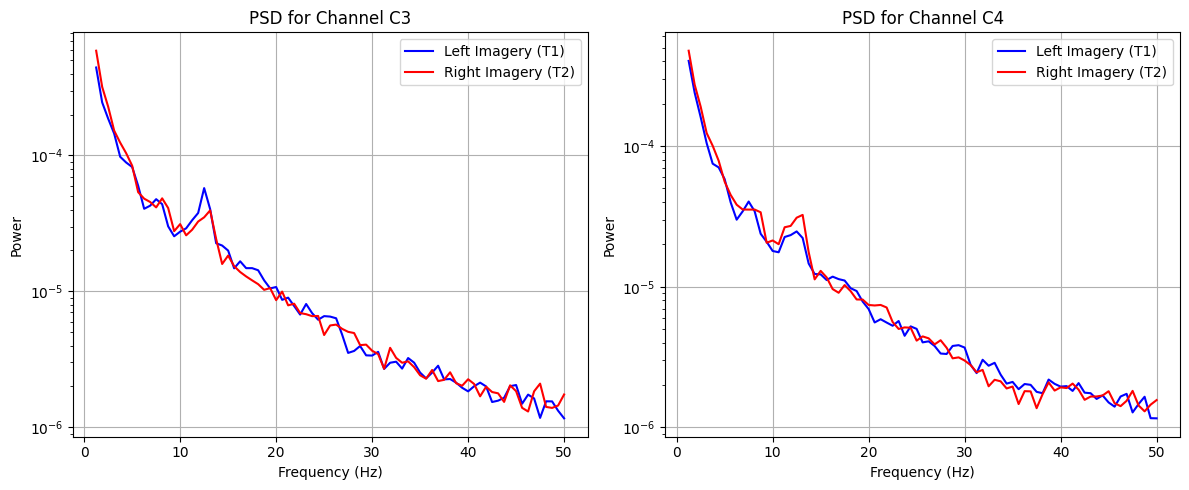

In [ ]:
#Run the same code as in step 11 only with epoch_all to get a better visualisation of the
#ERD with more data and trials. We can now clearly see the dip in power due to an ERD in the mu band.

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
channels = ['C3', 'C4']
for i, channel_name in enumerate(channels):
    #get the channel name.
    pick = mne.pick_channels(epochs.ch_names, include=[channel_name])
    #Compute the PSD for left imagery epochs/trials using Welch method. This gives us the average power
    #at each frequency across all trials for the left imagery condition (C4, T1).
    psd_left = epochs_all['T1'].compute_psd(method='welch', picks=pick, fmin=1, fmax=50,
                                        n_fft=256)
    #Extract data from psd_left. This gives 3D array (n_epochs, n_channels, n_freqs). mean(axis=0)
    #averages across all trials to give us average power at each frequency. squeeze() removes
    #any single dimensions such as the channel.
    psd_left_data = psd_left.get_data().mean(axis=0).squeeze()
    freqs_left = psd_left.freqs

    #Same for right imagery (C3, T2).
    psd_right = epochs_all['T2'].compute_psd(method='welch', picks=pick, fmin=1, fmax=50,
                                         n_fft=256)
    psd_right_data = psd_right.get_data().mean(axis=0).squeeze()
    freqs_right = psd_right.freqs

    #plot with log scale on y-axis to better visualise differences in power across frequencies.
    ax[i].plot(freqs_left, psd_left_data*1e6, label='Left Imagery (T1)', color='blue')
    ax[i].plot(freqs_right, psd_right_data*1e6, label='Right Imagery (T2)', color='red')
    ax[i].set_xlabel('Frequency (Hz)')
    ax[i].set_ylabel('Power')
    ax[i].set_title(f'PSD for Channel {channel_name}')
    ax[i].legend()
    ax[i].set_yscale('log')
    ax[i].grid(True)
plt.tight_layout()
plt.show()

Part 13: Make a time frequency decomposition (Spectogram). Here we see how power at each frequency changes over time, aligned with different imegary cues. This willshow ERD actually happening rather than just the average difference. We will have time on one axis, frequency on the other and power represented by color, whereas before we collapsed the time dimension. We use Morlet Wavelets, which are short burst of oscillation at a specific frequency. By sliding these wavelets across the signal at different frequencies we can match the internal frequencies to the wavelet, and thereby estimate when those frequencies make up the bulk of the signal (where they have the most power), and this gives us our time dimension. This sliding is called convolving.

So the pipeline is roughly:
choose frequencies, say 4 to 30 Hz
build one Morlet wavelet per frequency
convolve each wavelet with each epoch
turn the complex result into power
average across trials if desired
plot frequency × time with color for power

Shorter wavelets lets you better estimate the timing of power better, while longer lets you better estimate the frequency you are observing. This is a tradeoff one must consider when making wavelets for different band frequencies.

Subject has quite weak ERD.

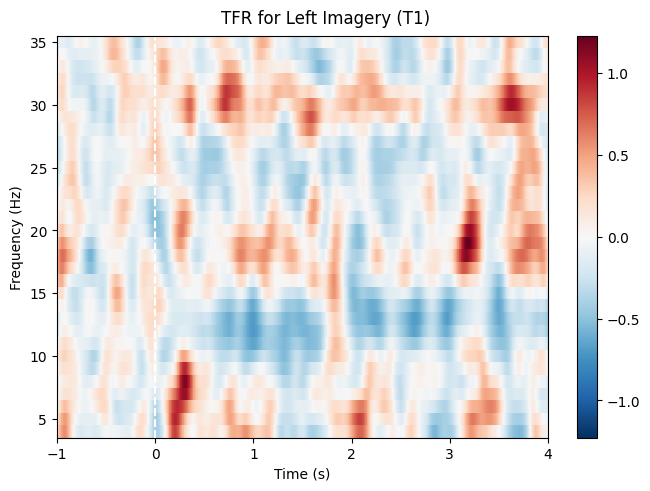

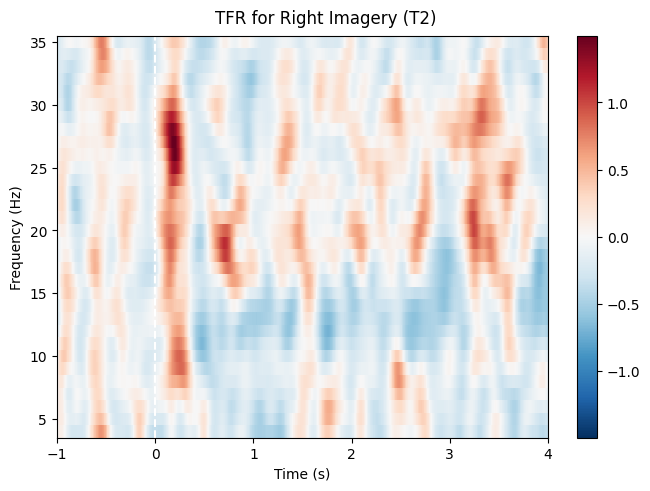

In [50]:
#We want to check frequencies from 4 to 35 Hz with a step of 1 Hz.
freqs_tfr = np.arange(4, 36, 1)
#The number of cycles in the Morlet wavelet is set to be half of the frequency we are checking.
#This is because higher frequencies have shorter cycles and lower frequencies have longer cycles.
n_cycles = freqs_tfr / 2.0
pick_c3 = mne.pick_channels(epochs.ch_names, include=['C3'])
#Time frequency representation for left imagery.
tfr_left = mne.time_frequency.tfr_morlet(epochs['T1'], freqs=freqs_tfr, n_cycles=n_cycles, 
                                         picks=pick_c3, return_itc=False, average=True)
#Same for right.
tfr_right = mne.time_frequency.tfr_morlet(epochs['T2'], freqs=freqs_tfr, n_cycles=n_cycles, 
                                         picks=pick_c3, return_itc=False, average=True)

#Plot side by side. We should expect to see a dip in power in the mu band for the right imagery as we
#are recording from C3. Basline = (-1, 0) means we are using the 1 second before the event onset as
#the baseline period to calculate the percentage change in power. Mode=percent shows percentage
#change form baseline, negative (ERD) will be blue and positive (ERS) will be red. 
fig_left = tfr_left.plot(title='TFR for Left Imagery (T1)', baseline=(-1, 0), mode='percent', show=False)
fig_left[0].axes[0].axvline(0, color='white', linestyle='--', linewidth=1.5)
fig_right = tfr_right.plot(title='TFR for Right Imagery (T2)', baseline=(-1, 0), mode='percent', show=False)
fig_right[0].axes[0].axvline(0, color='white', linestyle='--', linewidth=1.5)

#Add a vertical line at time 0 to indicate the event onset. 
plt.show()




Part 14: We build a topographic map of the ERD pattern. We visualise where on the scalp the power difference between right and left imagery is strongest. This produces a brain heatmap. Instead of focusing on 1 or 2 channels, we compute mu band power for all 64 channels during each condition (left vs right), then plot the difference on a map of the head. The difference should be strongest over motor cortex (C3, C4)

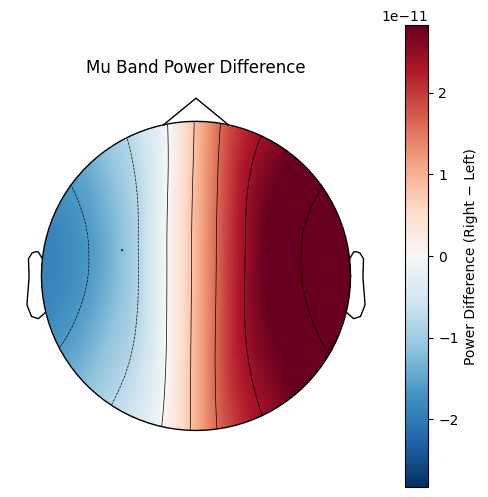

In [57]:
#We bandpass filter the epochs to focus on mu band (8-13 Hz).
epochs_mu = epochs_all.copy().filter(8, 13,)

#Get data for left and right imagery conditions. This gives us a 3D array (trials, channels, times).
#This is the data we will use to train our model. 
data_left = epochs_mu['T1'].get_data()
data_right = epochs_mu['T2'].get_data()
#We want only the imagery period.
period_mask = (epochs_mu.times >=0) & (epochs_mu.times <=4)
left_imagery = data_left[:, :, period_mask]
right_imagery = data_right[:, :, period_mask]
#We want to estimate the power in the mu band for each trial for each condition. We do this by
#calculating the variance across time points for each trial (measuring the oscillation strength).
#This gives a 2D array (trials, channels) where each value represent the mu power.
left_power = np.var(left_imagery, axis=2)
right_power = np.var(right_imagery, axis=2)
#Average across trials to get one number for each channel represent the average mu power for that
#condition.
left_power_mean = left_power.mean(axis=0)
right_power_mean = right_power.mean(axis=0)

#Compute the difference in mu power between left and right imagery for each channel.
#Negative value indicates right imagery had less power. ERD for right hand.
#Positive value indicates left imagery had less power. ERD for left hand.
power_diff = right_power_mean - left_power_mean

#Plot as a topographic map.
fig, ax = plt.subplots(figsize=(6, 6))
im, _ = mne.viz.plot_topomap(power_diff, epochs_mu.info, axes=ax, show=False)
plt.colorbar(im, ax=ax, label='Power Difference (Right − Left)')
ax.set_title('Mu Band Power Difference')
plt.show()
